### ANOVA tests
Eşleştirilmemiş ve eşleştirilmiş durumlarda iki grubu nasıl karşılaştıracağı anlatıldı. Peki ya ikiden fazla grup varsa?

In [1]:
import pandas as pd

df_stck = pd.read_feather("resources/stack_overflow.feather")
df_stck['job_sat'].value_counts()

# Stack Overflow anketi, "Çok memnunum"dan "Hiç memnun değilim"e kadar beş kategori

job_sat
Very satisfied           879
Slightly satisfied       680
Slightly dissatisfied    342
Neither                  201
Very dissatisfied        159
Name: count, dtype: int64

**Çoklu dağılımları görselleştirme**

Ortalama yıllık ücretin her bir iş tatmini seviyesi için farklı olup olmadığının bilinmek istendiğini varsayalım.
Yapılacak ilk şey dağılımları kutu grafikleri ile görselleştirmektir. Seaborn'un boxplot yöntemi burada stack_overflow verilerini kullanarak yatay eksende converted_comp ve dikey eksende job_sat ile güzel bir seçenek sunmaktadır. "Çok memnunum" diğerlerinden biraz daha yüksek görünüyor, ancak önemli ölçüde farklı olup olmadıklarını görmek için hipotez testleri kullanmak gerekmektedir.

<Axes: xlabel='converted_comp', ylabel='job_sat'>

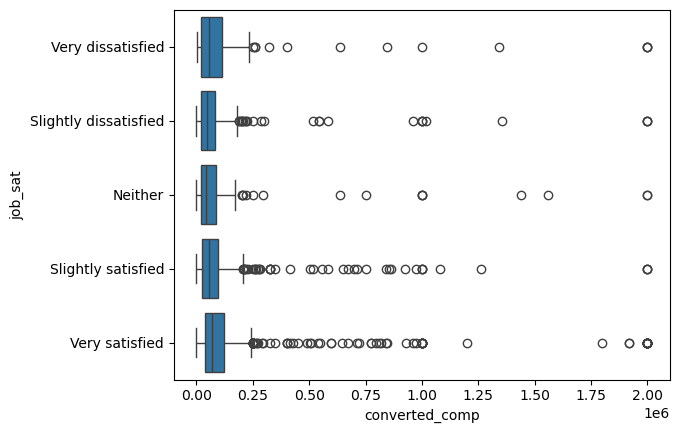

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="converted_comp",y="job_sat",data=df_stck)

**Analysis of variance (ANOVA)**

ANOVA testleri gruplar arasında farklılık olup olmadığın belirler. Anlamlılık düzeyi 0.2 olarak belirlendi.
Bu değer birçok durumda olduğundan daha büyüktür, ancak daha sonra farklı sayıdaki grupları karşılaştırmanın sonuçarını anlamaya yardımcı olacaktır. Birden fazla gruptaki değerleri karşılaştırmak için pingouin anova yöntemi kullanılacak. Verileri stack_overflow, bağımlı değişken olan dv'yi converted_comp ve aralarında hesaplama yapılacak grup sütunu job_sat olarak belirlenir. p-değeri, p-unc sütununda saklanır; bu sütun, alfa değerinden yüzde 20 daha küçük olan 0.0013 noktasıdır. Bu, iş tatmini kategorilerinden en az ikisinin ücret düzeyleri arasında önemli farklılıklar olduğu anlamına gelir, ancak bu bize hangi iki kategori olduğunu söylemez.

In [3]:
import pingouin

pingouin.anova(data=df_stck,dv="converted_comp",between="job_sat")

#p değeri < alfa oldupundan sıfır hipotezi reddediyoruz. Yani gruplar arasında fark vardır. En az ikisi arasında fark vardır. 5 grup var çünkü

,Source,ddof1,ddof2,F,p-unc,np2
0,job_sat,4,2256,4.480485,0.001315,0.007882


# Pairwise Tests

Hangi kategorilerin farklı olduğunu belirlemek için, beş iş memnuniyeti kategorisinin tamamını karşılaştırarak her bir çift sırayla test edilmelidir. Beş maddelik bir setten iki madde seçmenin on yolu vardır, dolayısıyla gerçekleştirilmesi gereken on test vardır. Anlamlılık düzeyi 0.2'dir.

### Karşılaştırmalar:
<table style="width:100%;">
    <tr>
        <td style="vertical-align: top; width: 50%;">
            <ul>
                <li>$ \mu_{\text{very dissatisfied}} \neq \mu_{\text{slightly dissatisfied}} $</li>
                <li>$ \mu_{\text{very dissatisfied}} \neq \mu_{\text{neither}} $</li>
                <li>$ \mu_{\text{very dissatisfied}} \neq \mu_{\text{slightly satisfied}} $</li>
                <li>$ \mu_{\text{very dissatisfied}} \neq \mu_{\text{very satisfied}} $</li>
                <li>$ \mu_{\text{slightly dissatisfied}} \neq \mu_{\text{neither}} $</li>
            </ul>
        </td>
        <td style="vertical-align: top; width: 50%;">
            <ul>
                <li>$ \mu_{\text{slightly dissatisfied}} \neq \mu_{\text{slightly satisfied}} $</li>
                <li>$ \mu_{\text{slightly dissatisfied}} \neq \mu_{\text{very satisfied}} $</li>
                <li>$ \mu_{\text{neither}} \neq \mu_{\text{slightly satisfied}} $</li>
                <li>$ \mu_{\text{neither}} \neq \mu_{\text{very satisfied}} $</li>
                <li>$ \mu_{\text{slightly satisfied}} \neq \mu_{\text{very satisfied}} $</li>
            </ul>
        </td>
    </tr>
</table>


### pairwise_tests()

Tüm bu hipotez testlerini tek seferde çalıştırmak için `pairwise_tests` yöntemi kullanılabilir. İlk üç argüman olan `data`, `dv` ve `between` anova metodu ile aynıdır. `p-adjust`'ı kısa bir süre sonra tartışacağız. Sonuç, A ve B'nin her satırda karşılaştırılan iki seviye olduğu bir DataFrame gösterir. Daha sonra, p-değerlerinin p-unc sütununa bakılır. Bunlardan üçü anlamlılık düzeyimiz olan sıfır nokta ikiden küçüktür.

In [4]:
import pingouin

pingouin.pairwise_tests(data=df_stck, dv='converted_comp', between='job_sat',padjust='none')
#6 ile 9. grup arasında anlamlı bir fark vardır. p value bakarak bunu söyleyebildik
#job_sat	Slightly dissatisfied
#job_sat	Slightly satisfied

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,job_sat,Very dissatisfied,Slightly dissatisfied,False,True,1.129951,247.570187,two-sided,0.259590,0.197,0.119131
1,job_sat,Very dissatisfied,Neither,False,True,0.545948,321.165726,two-sided,0.585481,0.135,0.058537
2,job_sat,Very dissatisfied,Slightly satisfied,False,True,1.243665,187.153329,two-sided,0.215179,0.208,0.145624
3,job_sat,Very dissatisfied,Very satisfied,False,True,-0.747379,221.666205,two-sided,0.455627,0.126,-0.063479
4,job_sat,Slightly dissatisfied,Neither,False,True,-0.602209,367.730081,two-sided,0.547406,0.118,-0.055707
5,job_sat,Slightly dissatisfied,Slightly satisfied,False,True,0.038264,569.926329,two-sided,0.969491,0.074,0.002719
6,job_sat,Slightly dissatisfied,Very satisfied,False,True,-3.076222,821.303063,two-sided,0.002166,7.43,-0.173247
7,job_sat,Neither,Slightly satisfied,False,True,0.700752,258.204546,two-sided,0.484088,0.114,0.068513
8,job_sat,Neither,Very satisfied,False,True,-1.662901,328.326639,two-sided,0.097286,0.337,-0.120115
9,job_sat,Slightly satisfied,Very satisfied,False,True,-4.009935,1478.622799,two-sided,0.000064,158.564,-0.192931


**Grup sayısı arttıkça...**

Bu durumda beş grup var ve sonuçta on çift elde edilir. Grup sayısı arttıkça çift sayısı -ve dolayısıyla gerçekleştirilmesi gereken hipotez testi sayısı-dört kat artar. Ne kadar çok test yapılırsa, bunlardan en az birinin yanlış pozitif anlamlı sonuç verme olasılığı o kadar yüksek olur. Anlamlılık düzeyi 0.2 olduğunda, bir test yapılırsa, yanlış pozitif sonuç olasılığı 0.2. Beş grup ve on testle en az bir yanlış pozitif olasılığı yaklaşık 0.7'dir. Yirmi grupla, en az bir yanlış pozitif alacağımız neredeyse garantidir.

**Bonferonni correction**

Bunun çözümü p-değerlerini artırmak için bir ayarlama uygulamak ve yanlış pozitif alma şansını azaltmaktır. Yaygın bir ayarlama Bonferonni düzeltmesidir. Düzeltilmemiş p-unc sütununun aksine, düzeltilmiş p-değerine karşılık gelen p-corr sütununa bakıldığında, çiftlerden yalnızca ikisinin önemli farklılıklara sahip olduğu görülmektedir. 

In [5]:
pingouin.pairwise_tests(data=df_stck, dv='converted_comp', between='job_sat',padjust='bonf')
#düzeltilmiş p. eğer elimizde çok fazla çift varsa, hata almayı azaltır. padjust=bonf düzeltme olan kısım burası

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,job_sat,Very dissatisfied,Slightly dissatisfied,False,True,1.129951,247.570187,two-sided,0.259590,1.000000,bonf,0.197,0.119131
1,job_sat,Very dissatisfied,Neither,False,True,0.545948,321.165726,two-sided,0.585481,1.000000,bonf,0.135,0.058537
2,job_sat,Very dissatisfied,Slightly satisfied,False,True,1.243665,187.153329,two-sided,0.215179,1.000000,bonf,0.208,0.145624
3,job_sat,Very dissatisfied,Very satisfied,False,True,-0.747379,221.666205,two-sided,0.455627,1.000000,bonf,0.126,-0.063479
4,job_sat,Slightly dissatisfied,Neither,False,True,-0.602209,367.730081,two-sided,0.547406,1.000000,bonf,0.118,-0.055707
5,job_sat,Slightly dissatisfied,Slightly satisfied,False,True,0.038264,569.926329,two-sided,0.969491,1.000000,bonf,0.074,0.002719
6,job_sat,Slightly dissatisfied,Very satisfied,False,True,-3.076222,821.303063,two-sided,0.002166,0.021659,bonf,7.43,-0.173247
7,job_sat,Neither,Slightly satisfied,False,True,0.700752,258.204546,two-sided,0.484088,1.000000,bonf,0.114,0.068513
8,job_sat,Neither,Very satisfied,False,True,-1.662901,328.326639,two-sided,0.097286,0.972864,bonf,0.337,-0.120115
9,job_sat,Slightly satisfied,Very satisfied,False,True,-4.009935,1478.622799,two-sided,0.000064,0.000638,bonf,158.564,-0.192931


**padjust:** *string*

##### Method used for testing and adjustment of pvalues

- `none`:no correction[default]
- `bonf`:one-step Bonferroni correction
- `sidak`:one-step Sidak correction
- `holm`:step-down method using Bonferonni adjustments
- `fdr_bh`:Benjamini/Hochberg FDR correction
- `fdr_by`:Benjamini/Yekutelli FDR correction

pinpouin p-değerini ayarlamak için bazıları diğerlerinden daha muhafazakar olan çeşitli seçenekler vardır. Hiçbir ayarlama yapılmaması varsayılandır, ancak neredeyse tüm ikili t-testi durumlarında bir düzeltme yöntemi seçmek daha uygundur.

**One-sample proportion tests**

Hipotez testleri, bilinmeyen bir popülasyon oranının belirli bir değere eşit olup olmadığını ölçtüğü anlaşılmıştı. Örneklem istatistiğinin standart
hatasını tahmin etmek için örneklem üzerinde bootstrapping kullanılmıştı. Standart hata daha sonra standartlaştırılmış bir test istatistiği olan z-skorunu hesaplamak için kullanıldı, bu da bir p-değeri elde etmek için kullanıldı, böylece boş hipotezin reddedilip reddedilemeyeceğine karar verebildi. Bir bootstrap dağılımını hesaplamak hesaplama açısından yoğun olabilir, bu nedenle bu sefer test istatistiğini hesaplamak yerine bootstrap olmadan hesaplama yapılacaktır.

**Standardized test statistic for proportions**

Bir oran veya kısaca popülasyon oranı olan bilinmeyen bir popülasyon parametresi p ile gösterilir. Örneklem oranı p-hat ile gösterilir ve popülasyon oranı için varsayılan değer p-sıfır ile gösterilir. Daha önce anlatıldığı gibi, standartlaştırılmış test istatistiği bir z-skordur. Bu, örneklem istatistiği ile başlayıp ortalaması çıkarılarak ve ardından standart hatasına bölünerek hesaplanabilir. p-hat eksi p-hat ortalaması, p-hat standart hatasına bölünür. Python'da örneklemeden p-hat ile gösterilen örneklem örnek ortalamalarının örnekleme dağılımının ortalamasının p, yani popülasyon oranı olduğunu hatırlayın. Sıfır hipotezi altında, bilinmeyen p oranının varsayılan popülasyon oranı p-sıfır olduğu varsayılır. Z-skoru artık p-hat eksi p-sıfırdır ve p-hat'in standart hatasına bölünür.

**p**: population proportion (unknown population parameter)  
**$\hat{p}$**: sample proportion (sample statistic)  
**$p_0$**: hypothesized population proportion  

### $z = \frac{\hat{p} - \text{mean}(\hat{p})}{SE(\hat{p})} = \frac{\hat{p} - p}{SE(\hat{p})}$

$Assuming (H_0) is true, (p = p_0), so:$

### $z = \frac{\hat{p} - p_0}{SE(\hat{p})}$


### Simplifying the standard error calculations

Oranlar için, $H_0$ altındа, $p-hat$ denkleminin standart hatası $p_0$ çarpı bir eksi $p_0$ olarak basitleştirilebilir, gözlem sayısına bölünür ve sonra kare köklü hale getirilir. Bunu $z-skor$ denkleminin yerine koyabiliriz. Bunu hesaplamak daha kolaydır çünkü sadece örneklemden elde edilen $hat{p}$ ve $n$ ile bizim seçtiğimiz $p_0$ değerlerini kullanır.

$SE_{\hat{p}} = \sqrt{\frac{p_0 \cdot (1 - p_0)}{n}} \rightarrow$ Under $H_0, SE_{\hat{p}}$ depends on hypothesized $p_0$ and sample size $n$.

Assuming $H_0$ is true,

### $z = \frac{\hat{p} - p_0}{\sqrt{\frac{p_0 \cdot (1 - p_0)}{n}}}$

* Only uses sample information $\hat{p}$ and $n$ and the hypothesized parameter $p_0$.

---

**Neden t yerine z?**

Neden burada $z-dağılımı$ kullanıldığı, ancak Bölüm 2'de $t-dağılımının$ kullanıldığı merak edilebilir. Bu, iki örneklem ortalaması durumu için test istatistiği denklemleridir. Örneklem standart sapması olan s, örneklem ortalaması olan $\bar{x}$'den hesaplanır. Bu da $\bar{x}$'ın payda popülasyon ortalamasını tahmin etmek için kullanıldığı anlamına gelir. Bu iki kullanım, popülasyon parametresi tahminimizdeki belirsizliği artırır. $t-dağılımı$ etkin bir şekilde daha kalın kuyruklu bir normal dağılım olduğundan, bu ekstra belirsizliği hesaba katmak için bunlar kullanılabilir. Aslında, $t-dağılımı$ boş hipotezin yanlışlıkla reddedilmesine karşı ekstra tedbir sağlar. Oranlar için, payda yerine $\hat{p}$ kullanılır, böylece belirsizlikle ilgili sorundan kaçınılır ve bir $z-dağılımı$ uygundur.

### $t = \frac{\bar{x}_{\text{child}} - \bar{x}_{\text{adult}}}{\sqrt{\frac{s_{\text{child}}^2}{n_{\text{child}}} + \frac{s_{\text{adult}}^2}{n_{\text{adult}}}}}$

- $s$ is calculated from $\bar{x}$.  
   - $\bar{x}$ estimates the population mean.
   - $s$ estimates the population standart deviaiton.
   - $\hat{p}$ only appears in the numerator, so z-scores are fine

**Stack Overflow age categories**

Stackoverflow veri setinde popülasyondaki kullanıcıların yarısının otuz yaş altında olduğunu varsayalım ve bir fark olup olmadığını kontrol edelim. Anlamlılık düzeyini 0.1 olarak belirleyelim. Örneklemde, kullanıcıların yarısından biraz fazlası otuz yaşın altındadır.

##### $H_0 :$ Proportion of Stack Overflow users under thirty = 0.5

##### $H_A :$ Proportion of Stack Overflow users under thirty $\neq$ 0.5

In [6]:
#stackoverflowdaki kullanıcıların yarısı otuz yaşın altında var sayalım. hipotez bu. anlamlılık değeri de 0.01
#h0  30 yaşının altındakilerin oranı yüzde elli
#h1 30 yaşının altındakilerin oranı yüzde elliden farklı

alpha =0.01
df_stck["age_cat"].value_counts()

age_cat
Under 30       1211
At least 30    1050
Name: count, dtype: int64

In [7]:
#z için değişkenler
#p_hat= sample'ın oranı
import numpy as np
'''
alpha =0.01
df_stck["age_cat"].value_counts(normalize = True)
bu da oranları getirecek şekilde çalışır
'''
p_hat=np.mean(df_stck["age_cat"]=="Under 30")
print(p_hat)

0.5356037151702786


In [8]:
p_0=0.5

In [9]:
n = len(df_stck)
n

2261

# $z = \frac{\hat{p} - p_0}{\sqrt{\frac{p_0 \cdot (1 - p_0)}{n}}}$

In [10]:
import numpy as np

pay = p_hat-p_0
payda = np.sqrt(p_0 *(1 - p_0) /n)
z_score = pay/payda
z_score

np.float64(3.385911440783663)

**Calculating the p-value**

Sol kuyruklu alternatif hipotezler için norm.cdf kullanarak z-skoru p-değerine dönüştürülür. Sağ kuyruklu alternatif hipotezler için norm.cdf sonucu birden çıkarılır. İki kuyruklu alternatif hipotezler için, test istatistiğinin her iki kuyrukta da yer alıp almadığı kontrol edilir, dolayısıyla p-değeri bu iki değerin toplamıdır; biri z-skoruna, diğeri de dağılımın diğer tarafındaki negatifine karşılık gelir. Normal dağılım PDF'si simetrik olduğundan, z-skoru pozitif olduğu için bu, sağ kuyruklu p-değerinin iki katı olarak basitleştirilir. Burada, p-değeri sıfır-bir noktasının anlamlılık düzeyinden küçüktür, bu nedenle sıfır hipotezini reddederek otuz yaşın altındaki kullanıcıların oranınının yüzde elliden anlamlı derecede farklı olduğu sonucuna varılır.

In [11]:
#bunu üstünde sağ ve sol kuyruk var, fotosunu çektim ekle!!!!!
#alternatif hipotezde az çok gibi şeyler yazılmadığından çift kuyruk kullanılır.

from scipy.stats import norm
p_value=2*(1-norm.cdf(z_score))
p_value

np.float64(0.0007094227368100725)

In [12]:
#bu da iki kuyruk ( aynı yani üsteki ile)
p_value=norm.cdf(-z_score)+1-norm.cdf(z_score)
p_value

np.float64(0.0007094227368100725)

In [13]:
'''
ho= hobi olarak kullanan kullanıcıların 30 yaş altı ve üstü oranları aynıdır
h1= farklıdır
'''
p_value <= alpha


np.True_

## Two-sample proportion tests

Ortalamalarda olduğu gibi, iki popülasyondaki oranlar arasındaki farklar da test edilebilir.

**Comparing two proportions**

Stack overflow anketi bir hobbyist değişkeni içermektedir. 'Evet' değeri kullanıcının kendisini hobici olarak tanımladığı, 'Hayır' değeri ise kendinisini profesyonel olarak tanımladığı anlamına gelmektedir. Hobi sahibi kullanıcıların oranının otuz yaş altı kategorisi ile otuz yaş üstü kategorisi için aynı olduğu varsayılabilir, bu da iki kuyruklu bir testtir. Daha açık bir ifadeyle, boş hipotez her bir grup için popülasyon parametreleri arasındaki farkın sıfır olduğudur. Anlamlılık düzeyini 0.5 olarak belirleyelim.

##### $H_0$:Proportion of hobbyist users in same for those under thirty as those at least thirty

##### $H_0:p \geq 30 - p < 30 = 0$

##### $H_A:$Proportion of hobbyist users is different for those under thirty as those at least thirty

##### $H_A:p \geq 30 - p < 30 \neq 0$

### Z-skorunun hesaplanması

- **z-score equation for a proportion test:**

### $z = \frac{(\hat{p}_{\geq 30} - \hat{p}_{<30}) - 0}{SE(\hat{p}_{\geq 30} - \hat{p}_{<30})}$

- **Standard error equation:**

### $SE(\hat{p}_{\geq 30} - \hat{p}_{<30}) = \sqrt{\frac{\hat{p} \cdot (1 - \hat{p})}{n_{\geq 30}} + \frac{\hat{p} \cdot (1 - \hat{p})}{n_{<30}}}$

- **$\hat{p}$ → weighted mean of $\hat{p}_{\geq 30}$ and $\hat{p}_{<30}$:**

### $\hat{p} = \frac{n_{\geq 30} \cdot \hat{p}_{\geq 30} + n_{<30} \cdot \hat{p}_{<30}}{n_{\geq 30} + n_{<30}}$

---

Örneklem istatistiği, her bir kategori için oranlardaki farktır. Bu, paydayı iki $\hat{p}$ değeri içerir. Popülasyon parametresinin varsayılan değerini çıkarırız ve boş hipotezin doğru olduğunu varsayarsak, sıfırdır. Payda, örneklem istatistiğinin standart hatasıdır. Tek örnek durumunun biraz daha karmaşık bir versiyonu olan standart hata denklemini kullanarak standart hatayı hesaplamak için bir bootstrap dağılımı oluşturmak yerine kaçınılabilir. $\hat{p}$’in her bir kategori için örnek oranlarının ağırlıklı ortalaması olduğunu ve popülasyon oranının havuzlanmış tahmini olarak da bilindiğini unutmayın. $\hat{p}$ aşağıdaki denklem kullanılarak hesaplanabilir. Bu korkunç görünüyorsa, ancak Python aritmetik işlemlerde harikadır. Şimdi bu hesaplamaları yapmak ve z-skorunu hesaplamak için örnek veri kümesinden sadece dört sayıya ihtiyacımız var: her yaş grubundaki hobicilerin oranı ve her yaş grubundaki gözlem sayısı.


In [14]:
import pandas as pd

df_stck = pd.read_feather("resources/stack_overflow.feather")
df_stck

,respondent,main_branch,hobbyist,age,age_1st_code,age_first_code_cut,comp_freq,comp_total,converted_comp,country,...,survey_length,trans,undergrad_major,webframe_desire_next_year,webframe_worked_with,welcome_change,work_week_hrs,years_code,years_code_pro,age_cat
0,36.0,"I am not primarily a developer, but I write co...",Yes,34.0,30.0,adult,Yearly,60000.0,77556.0,United Kingdom,...,Appropriate in length,No,"Computer science, computer engineering, or sof...",Express;React.js,Express;React.js,Just as welcome now as I felt last year,40.0,4.0,3.0,At least 30
1,47.0,I am a developer by profession,Yes,53.0,10.0,child,Yearly,58000.0,74970.0,United Kingdom,...,Appropriate in length,No,"A natural science (such as biology, chemistry,...",Flask;Spring,Flask;Spring,Just as welcome now as I felt last year,40.0,43.0,28.0,At least 30
2,69.0,I am a developer by profession,Yes,25.0,12.0,child,Yearly,550000.0,594539.0,France,...,Too short,No,"Computer science, computer engineering, or sof...",Django;Flask,Django;Flask,Just as welcome now as I felt last year,40.0,13.0,3.0,Under 30
3,125.0,"I am not primarily a developer, but I write co...",Yes,41.0,30.0,adult,Monthly,200000.0,2000000.0,United States,...,Appropriate in length,No,None,None,None,Just as welcome now as I felt last year,40.0,11.0,11.0,At least 30
4,147.0,"I am not primarily a developer, but I write co...",No,28.0,15.0,adult,Yearly,50000.0,37816.0,Canada,...,Appropriate in length,No,"Another engineering discipline (such as civil,...",None,Express;Flask,Just as welcome now as I felt last year,40.0,5.0,3.0,Under 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2256,62812.0,I am a developer by profession,Yes,40.0,10.0,child,Yearly,145000.0,145000.0,United States,...,Too long,No,"Computer science, computer engineering, or sof...",Flask;jQuery,Angular;Angular.js;Flask;jQuery;React.js,Somewhat less welcome now than last year,50.0,30.0,20.0,At least 30
2257,62835.0,I am a developer by profession,Yes,23.0,9.0,child,Monthly,180000.0,33972.0,Russian Federation,...,Too short,No,"Computer science, computer engineering, or sof...",ASP.NET Core,ASP.NET Core;Flask,Just as welcome now as I felt last year,60.0,8.0,3.0,Under 30
2258,62837.0,I am a developer by profession,Yes,27.0,8.0,child,Monthly,7500.0,97284.0,Germany,...,Appropriate in length,No,Mathematics or statistics,None,None,Just as welcome now as I felt last year,42.0,12.0,2.0,Under 30
2259,62867.0,"I am not primarily a developer, but I write co...",Yes,33.0,13.0,child,Monthly,6000.0,72000.0,Panama,...,Too long,No,"Another engineering discipline (such as civil,...",None,Django;React.js,A lot less welcome now than last year,45.0,15.0,2.0,At least 30


In [15]:
p_hats = df_stck.groupby('age_cat')['hobbyist'].value_counts(normalize=True)
p_hats


age_cat      hobbyist
At least 30  Yes         0.773333
             No          0.226667
Under 30     Yes         0.843105
             No          0.156895
Name: proportion, dtype: float64

In [50]:
n = df_stck.groupby('age_cat')['hobbyist'].count()
n

age_cat
At least 30    1050
Under 30       1211
Name: hobbyist, dtype: int64

In [17]:
p_hat_at_least_30 = p_hats[('At least 30', 'Yes')]
p_hat_at_under_30 = p_hats[('Under 30', 'Yes')] #tuple olarak verilmiş
(p_hat_at_least_30, p_hat_at_under_30)


(np.float64(0.7733333333333333), np.float64(0.8431048720066061))

In [18]:
n_at_least_30 = n['At least 30']
n_at_under_30 = n['Under 30']
(n_at_least_30,n_at_under_30)

(np.int64(1050), np.int64(1211))

In [19]:
#p değeri ve z değeri hesaplama burada ( formülün aynısı ) 
import numpy as np
p_hat = (n_at_least_30 * p_hat_at_least_30 + n_at_under_30 * p_hat_at_under_30) / (n_at_least_30 + n_at_under_30)

std_error = np.sqrt(p_hat * (1 - p_hat) / n_at_least_30 +
                    p_hat * (1 - p_hat) / n_at_under_30)

z_score = (p_hat_at_least_30 - p_hat_at_under_30) / std_error

z_score

np.float64(-4.223691463320559)

In [20]:
from scipy.stats import norm

p_value = 2 * (1 - norm.cdf(abs(z_score)))
p_value

np.float64(2.4033301426751308e-05)

**Proportion tests using proportions_ztest()**

Statsmodels'in proportions_ztest fonksiyonu z-skorunu daha doğrudan hesaplayabilir. Bu fonksiyon NumPy dizileri olarak iki nesne gerektirir: her yaş grubundaki hobicileri sayısı ve her yaş grubundaki toplam satır sayısı. Bu sayılar age_cate göre gruplandırılarak ve hobi sahibi sütununda “value_counts” çağrılarak elde edilebilir. Sayılar daha sonra okunabilir ya da dizileri oluşturmak için alt kümeleye ayrılabilir.

Ardından, statsmodels.stats.proportionsdan proportions_ztesti çağırarak ve dizileri count ve nobs argümanlarına aktarıyoruz. Bir fark test ettiğimiz için, alternatif argümanını kullanarak bunun iki taraflı bir test olduğunu belirtiyoruz. proportions_ztest, bize bir z-skoru ve bir p-değeri döndürür. P-değeri, belirttiğimiz yüzde beş anlamlılık düzeyinden daha küçüktür, bu nedenle iki yaş grubu arasında hobi oranlarında bir fark olduğu sonucuna varabiliriz.



In [21]:
df_stck.groupby("age_cat")["hobbyist"].value_counts()

age_cat      hobbyist
At least 30  Yes          812
             No           238
Under 30     Yes         1021
             No           190
Name: count, dtype: int64

In [22]:
#yukarda yaptıklarımızın aynısını daha kolay yapan bir fonksiyondur.
n_hobbyist = np.array([812, 1021])
n_rows = np.array([812 + 238, 1021 + 190])

from statsmodels.stats.proportion import proportions_ztest

z_score,p_value = proportions_ztest(count=n_hobbyist, nobs=n_rows,alternative='two-sided') # z score ve p value döndürür

(z_score,p_value)
#h0 reddedilir

(np.float64(-4.223691463320559), np.float64(2.403330142685068e-05))

### Chi-square test of independence (Ki-Kare bağımsızlık testi)

ANOVA'nın t-testlerini ikiden fazla gruba genişletmesi gibi, ki-kare bağımsızlık testleri de orantı testlerini ikiden fazla gruba genişletir.

Ki-Kare Testi, kategorik değişkenler arasında anlamlı bir ilişki olup olmadığını veya gözlenen verilerin belirli bir hipotez altında beklenen verilerden anlamlı bir şekilde sapıp sapmadığını belirlemek için kullanılan istatistiksel bir yöntemdir. Genellikle kategorik veriler için hipotez testinde kullanılır.

#### Değişkenlerin bağımsızlığı

Bir önceki ders yapılan oran testi pozitif sonuç vermiştir. Küçük p-değeri, hobici ve yaş kategorisi değişkenlerinin bir ilişkisi olduğuna dair kanıt olduğunu göstermiştir. Eğer hobicilerin oranı her yaş kategorisi için aynı olsaydı, değişkenler istatistiksel olarak bağımsız kabul edilirdi. Daha resmi bir ifadeyle, yanıt değişkenindeki başarı oranı açıklayıcı değişkenin tüm kategorilerinde aynı olduğunda iki kategorik değişken istatistiksel olarak bağımsız kabul edilir.

#### Değişkenlerin bağımsızlığı için test

Pingouin paketi, önceki videodaki oranlardaki farkı test etmek için dolaylı bir yol sunar. chi2_independence yöntemine veri olarak stack_overflow, x olarak hobbyist ve y olarak age_cat değerlerini aktarıyoruz. Düzeltme argümanı, örneklem büyüklüğünün çok küçük ve serbestlik derecesinin bir olduğu durumlar için geçici bir faktör olan Yates'in süreklilik düzeltmesinin uygulanıp uygulanmayacağını belirtir. Her grubun yüzden fazla gözlemi olduğundan, burada buna ihtiyacımız yok. Yöntem üç farklı pandas DataFrame döndürür: beklenen sayılar, gözlenen sayılar ve testle ilgili istatistikler. İstatistiklere bakalım ve pearson test satırı ile chi2 ve pval sütunlarına odaklanalım. P-değeri, z-testinde elde ettiğimiz yüz binde iki değeriyle aynıdır. Chi2 değeri, önceki videoda gördüğümüz z-skorumuzun kareli sonucudur.



In [23]:
import pingouin

expected, observed, stats = pingouin.chi2_independence(data=df_stck, x='hobbyist', y='age_cat',correction=False)

stats
#pearsondaki chi2 =bir öncekinin z değerinin karesini veriyor 

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,17.839570,1.0,0.000024,0.088826,0.988205
1,cressie-read,0.666667,17.818114,1.0,0.000024,0.088773,0.988126
2,log-likelihood,0.000000,17.802653,1.0,0.000025,0.088734,0.988069
3,freeman-tukey,-0.500000,17.815060,1.0,0.000024,0.088765,0.988115
4,mod-log-likelihood,-1.000000,17.848099,1.0,0.000024,0.088848,0.988236
5,neyman,-2.000000,17.976656,1.0,0.000022,0.089167,0.988694


In [24]:
n = df_stck['age_cat'].value_counts()
n


age_cat
Under 30       1211
At least 30    1050
Name: count, dtype: int64

#### Job satisfaction and category

Başka bir örnek deneyelim. Stack overflow örnekleminin iki kategorili bir yaş kategorisi değişkenine ve beş kategorili bir iş memnuniyeti değişkenine sahip olduğunu hatırlayın.

In [25]:
# 'job_sat' sütunundaki değer sayımlarını hesapla
job_sat_counts = df_stck['job_sat'].value_counts()
job_sat_counts


job_sat
Very satisfied           879
Slightly satisfied       680
Slightly dissatisfied    342
Neither                  201
Very dissatisfied        159
Name: count, dtype: int64

### Hipotezlerin beyan edilmesi

Bu değişkenlerin bağımsızlığını test etmek için hipotezler beyan edebiliriz. Burada yaş kategorisi yanıt değişkeni, iş tatmini ise açıklayıcı değişkenidir. Boş hipotez, bağımsızlığın gerçekleştiğidir. 0.1’lik anlamlılık düzeyi kullanalım. Test istatistiği ki-kare ($\chi^2$) olarak gösterilir. Bağımsızlığın doğru olması durumunda gözlenen sonuçların beklenen değerlerden ne kadar uzak olduğunu ölçer.

$H_0$: Yaş kategorileri iş tatmini düzeylerinden bağımsızdır.  
$H_A$: Yaş kategorileri iş tatmini düzeylerinden bağımsız değildir.

### Exploratory visualization: proportional stacked bar plot (Keşifsel görselleştirme: orantılı yığılmış çubuk grafiği)

Orantılı yığılmış çubuk grafiği kullanarak verileri inceleyelim. Her yaş grubundaki oranlar hesaplanarak başlanır. Ardından, bu tabloyu geniş biçime dönüştürmek için unstack yöntemi kullanılır. Çizim yöntemini kullanıp kind bar ve stacked True olarak ayarlandığında orantılı yığınlanmış bir çubuk çizimi elde edilir.

Ki-kare testini değişkenler yer değiştirmiş olarak çalıştırırsak, sonuçlar aynı olacaktır. Bu nedenle, sorularımızı “X değişkeni Y değişkeninden bağımsız mı?” yerine “X ve Y değişkenleri bağımsız mı?” şeklinde ifade ediyoruz, çünkü sıralama önemli değil.


In [26]:
props = df_stck.groupby('job_sat')['age_cat'].value_counts(normalize=True)
props
# Bu text olarak, age cat, job sat aralarındaki oranları gösterir

C:\Users\Simse\AppData\Local\Temp\ipykernel_11844\1948637791.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  props = df_stck.groupby('job_sat')['age_cat'].value_counts(normalize=True)


job_sat                age_cat    
Very dissatisfied      Under 30       0.509434
                       At least 30    0.490566
Slightly dissatisfied  Under 30       0.532164
                       At least 30    0.467836
Neither                Under 30       0.567164
                       At least 30    0.432836
Slightly satisfied     Under 30       0.564706
                       At least 30    0.435294
Very satisfied         Under 30       0.511945
                       At least 30    0.488055
Name: proportion, dtype: float64

<img src="https://miro.medium.com/v2/resize:fit:828/format:webp/0*AsK-EkbNYMGb6WtN.png" 
     alt="stacked-unstack" 
     width="500" 
     height="600">

In [27]:
wide_props = props.unstack()#yukardakinin düzenlenmiş hali
wide_props # unstack(), yığından çıkartmak, geniş format haline dönüştürür

age_cat,At least 30,Under 30
job_sat,,
Very dissatisfied,0.490566,0.509434
Slightly dissatisfied,0.467836,0.532164
Neither,0.432836,0.567164
Slightly satisfied,0.435294,0.564706
Very satisfied,0.488055,0.511945


<Axes: xlabel='job_sat'>

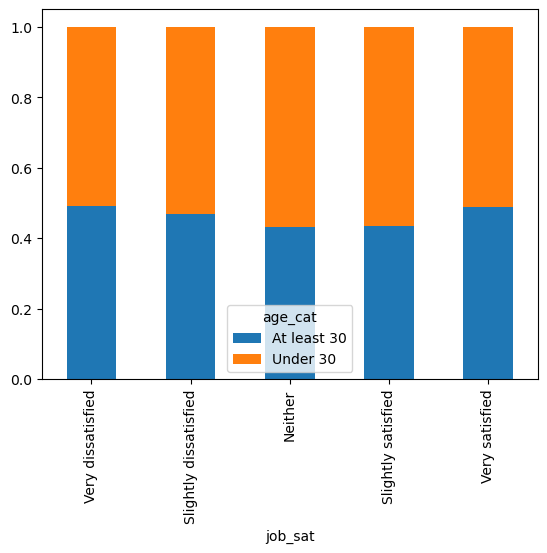

In [28]:
wide_props.plot(kind='bar', stacked=True)

Eğer yaş kategorisi iş memnuniyetinden bağımsız olsaydı, yaş kategorileri arasındaki ayrım beş çubuğun her birinde aynı yükseklikte olurdu. Burada bir miktar farklılık var, ancak bunun anlamlı bir fark olup olmadını belirlemek için ki-kare bağımsızlık testine ihtiyacımız olacaktır.

In [29]:
expected, observed, stats = pingouin.chi2_independence(data=df_stck, x='job_sat', y='age_cat')
stats

#p>alfa , birbiriden bağımsız olduğunun sonucuna varıyoruz.

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,5.552373,4.0,0.235164,0.049555,0.437417
1,cressie-read,0.666667,5.554106,4.0,0.235014,0.049563,0.437545
2,log-likelihood,0.000000,5.558529,4.0,0.234632,0.049583,0.437871
3,freeman-tukey,-0.500000,5.562688,4.0,0.234274,0.049601,0.438178
4,mod-log-likelihood,-1.000000,5.567570,4.0,0.233854,0.049623,0.438538
5,neyman,-2.000000,5.579519,4.0,0.232828,0.049676,0.439419


Yine pingouin'deki ki-kare bağımsızlık testini kullanalım. Veri olarak stack_overflow, x ve y olarak da job_sat ve age_cat değerlerine sahibiz. *Serbestlik derecemiz* dört olduğu için burada bir düzeltme yapmıyoruz, değişken kategorilerinin her birinden bir çıkarıp çarparak hesaplıyoruz. P-değeri, belirlediğimiz anlamlılık düzeyinin üzerinde olan 0.23'tür, bu nedenle yaş kategorisinin iş memnuniyetinden bağımsız olduğu sonucuna varıyoruz.


<Axes: xlabel='age_cat'>

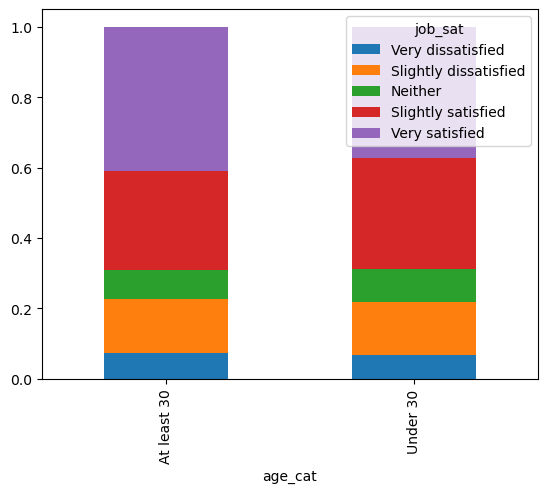

In [30]:
props = df_stck.groupby('age_cat')['job_sat'].value_counts(normalize=True)
wide_props = props.unstack()
wide_props.plot(kind='bar',stacked=True)
# her bir çubuk için bölünmelerin benzer yerlerde olduğunu görüyoruz.

In [31]:
expected, observed, stats = pingouin.chi2_independence(data=df_stck, x='age_cat',y='job_sat')
stats[stats['test']=='pearson']

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.0,5.552373,4.0,0.235164,0.049555,0.437417


**Yöne ve Kuyruklar**

Bu testte kuyruklar hakkında endişelenmedik ve aslında chi2_independence yönteminin alternatif bir argümanı yoktur. Bunun nedeni ki-kare test istatistiğinin gözlenen ve beklenen sayıların karesine dayanması ve kare sayıların negatif olmamasıdır. Bu da ki-kare testlerinin sağ kuyruklu testler olma eğiliminde olduğu anlamına gelir.

**Sol kuyruklu ki-kare testleri istatistiksel adli tıpta bir uyumun şüpheli derecede iyi olup olmadığını tespit etmek için kullanılır çünkü veriler uydurulmuştur. Ki-kare varyans testleri iki kuyruklu olabilir. Yine de bunlar niş kullanımlardır.**

### Ki-kare uyum iyiliği testleri (Chi-square goodness of fit tests)

Tek örneklem ki-kare testine uyum iyiliği testi denir, çünkü varsayılan verilerin gözlemlenen verilere ne kadar iyi uyduğu test edilir. Testi çalıştırmak için scipy.stats'taki chisquare yöntemi kullanılır. Chisquare için iki gerekli argüman vardır: gözlenen sayılar için dizi benzeri bir nesne, f_obs ve beklenen sayılar için bir tane, f_exp. Fonksiyon tarafından döndürülen p-değeri çok küçüktür, 0.01 anlamlılık düzeyinden çok daha düşüktür, bu nedenle oranların örnek dağılımının varsayılan dağılımdan farklı olduğu sonucuna varırız.

### Mor bağlantılar (Purple links)

Stack Overflow anketi, kullanıcıların bir kodlama problemini çözmeye çalışırken mor bağlantı olarak da adlandırılan en iyi kaynağa zaten ziyaret ettiklerini keşfettiklerinde nasıl hissettiklerine dair eğlenceli bir soru içeriyor. `purple_link` sütunundaki her bir grubun sayısını almak için `value_counts` fonksiyonu kullanılabilir. Ayrıca, daha sonra üzerinde çalışılabilecek güzel yapılandırılmış bir DataFrame elde etmek için burada biraz manipülasyon yapılmaktadır. İlk olarak, en soldaki sütun `purple_link` olarak yeniden adlandırılır, sayılar yeni bir sütun olarak `purple_link`e göre sıralı, böylece yanıtlar alfabetik sırada olur. `purple_link` sütununda saklanan dört olası yanıt vardır.


In [32]:
# Mor bağlantı, kodlama problemini çözmeye çalışırken mor bağlantı olarak kaynağı ziyaret
purple_link_counts=df_stck["purple_link"].value_counts()
purple_link_counts

purple_link
Hello, old friend    1225
Indifferent           405
Amused                368
Annoyed               263
Name: count, dtype: int64

In [33]:
purple_link_counts = purple_link_counts.rename_axis('purple_link').reset_index(name='n').sort_values('purple_link')

purple_link_counts

,purple_link,n
2,Amused,368
3,Annoyed,263
0,"Hello, old friend",1225
1,Indifferent,405


In [34]:
hypothesized = pd.DataFrame({
    'purple_link' : ['Amused', 'Annoyed', 'Hello, old friend', 'Indifferent'],
    'prop' : [1/6, 1/6, 1/2, 1/6]
}
)
hypothesized

,purple_link,prop
0,Amused,0.166667
1,Annoyed,0.166667
2,"Hello, old friend",0.500000
3,Indifferent,0.166667


$H_0$:Örneklem, varsayılan dağılımla eşleşmektedir.

$H_A$: Örneklem, varsayılan dağılımla eşleşmemektedir.

$\chi^2$, her grupta gözlemlenen sonuçların beklentilerden ne kadar uzak olduğunu ölçer.

In [35]:
alpha=0.01

In [36]:
# Kategoriye göre varsayılan sayılar
# Purple link dağılımını görselleştirmek için,
# her bir yanıt için varsayılan sayıların bulunması yardımcı olacaktır.
# Bu sayılar, varsayılan oranların örneklemdeki
# toplam gözlem sayısıyla çarpılmasıyla hesaplanır.
n_total = len(df_stck)
hypothesized['n'] = hypothesized['prop'] * n_total
hypothesized


,purple_link,prop,n
0,Amused,0.166667,376.833333
1,Annoyed,0.166667,376.833333
2,"Hello, old friend",0.500000,1130.500000
3,Indifferent,0.166667,376.833333


**Visualizing Counts**

Varsayılan sayıların gözlemlenen sayıları ne kadar iyi modellediğini görmek için bir görselleştirme oluşturalım. Kategorik bir değişkenin sayılarını görselleştirmenin doğal yolu bir çubuk grafiğidir. İlk olarak, gözlenen purple_link sayılarını çizmek için plt.bar kullanılır, yatay eksen purple_link ve dikey eksen n olarak ayarlanır. Aynı şey varsayılan sayılar için de yapılır, ancak alfa bağımsız değişkeniyle şeffaflık da eklenir.

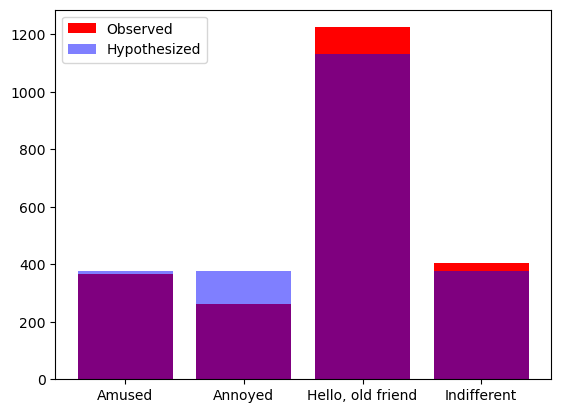

In [37]:
import matplotlib.pyplot as plt

plt.bar(purple_link_counts['purple_link'], purple_link_counts['n'], color='red', label='Observed')
plt.bar(hypothesized['purple_link'], hypothesized['n'], alpha=0.5, color='blue', label='Hypothesized')
plt.legend()

Yanıtlardan ikisinin varsayılan dağılım tarafından makul ölçüde iyi modellendiğini ve diğer ikisinin oldukça farklı göründüğünü görebiliriz, ancak farkın istatistiksel olarak anlamlı olup olmadığını görmek için bir hipotez testi yapmamız gerekecektir.

**chi-square goodness of fit test(ki-kare uyum iyiliği testleri)**

Tek örneklem ki-kare testine uyum iyiliği testi denir, çünkü varsayılan verilerin gözlemlenen verilere ne kadar iyi uyduğu test edilir. Testi çalıştırmak için scipy.stats'daki chisquare yöntemi kullanılır. Chisquare için gerekli iki argüman vardır:
- Gözlenen sayılar için dizi benzeri bir nesne,
- f_obs ve beklenen sayılar için bir tane f_exp.
Fonksiyon tarafından döndürülen p-değeri çok küçüktür, 0.01 anlamlılık düzeyinden çok daha düşüktür, bu nedenle oranların örnek dağılımının varsayılan dağılımdan farklı olduğu sonucuna varırız.

In [38]:
from scipy.stats import chisquare
chisquare(f_obs=purple_link_counts['n'], f_exp=hypothesized['n'])

'''
f_obs: gözlemlenen veriler

f_exp: beklenen veriler

Test bu iki diziyi karşılaştırır, gözlem dağılımının beklenen dağılıma ne kadar uyduğuna bakılır.
'''

'\nf_obs: gözlemlenen veriler\n\nf_exp: beklenen veriler\n\nTest bu iki diziyi karşılaştırır, gözlem dağılımının beklenen dağılıma ne kadar uyduğuna bakılır.\n'

##### Assumption in hypothesis testing(Hipotez testinde varsayımlar)

Şimdiye kadar görülen her hipotez testi veriler hakkında varsayımlarda bulunur. Sadece bu varsayımlar karşılandığında o hipotez testini kullanak uygun olur.

##### Randomness (Rastgelelik)

İster bir ister birden fazla örnek kullanılsın, her hipotez testi her bir örneğin popülasyondan rastgele seçildiğini varsayar. Eğer rastgele bir örneklem yoksa, o zaman popülasyonu temsil edemeyecektir. Bu varsayımı kontrol etmek için verilerin nereden geldiğinin bilinmesi gerekir. Bunu kontrol etmek için yapılabilecek istatistiksel veya kodlama testleri yoktur. Şüpheye düşülürse, veri toplamayla dahil olan kişilere veya örneklemenin popülasyonu almayıp bir alt uzmanın sorunlara gerek duyulması gerekir.

##### Independence of observations (Gözlemlerin Bağımsızlığı)

Testler ayrıca her bir gözlemin bağımsız olduğunu varsayar. İki örnek arasındaki bağımlılıklarla izin verilen eşleştirilmiş t-testleri gibi bazı özel durumlar vardır, ancak bunlar hesaplamaları değiştirir, bu nedenle bu tür bağımlılıkların nerede meydana geldiğini anlamamız gerekir. Eşleştirilmiş t-testine girdiğinde, bu bağımlılıkların hesaba katılmaması yanlış negatif ve yanlış pozitif hata oluşmasını imkansız kılar. Test bağımlılıkların hesaba katılmaması, analiz sırasında teşhis edilmesi zor bir sorundur. İdeal olarak, veriler analiz edilmeden önce tartışılması gerekir.

##### Large sample size (Büyük örneklem büyüklüğü)

Tek örneklemli t-testleri için popüler bir sezgisel yöntem, örneklemde en az 30 gözleme ihtiyaç olduğudur. İki örneklemli durum veya ANOVA için, her gruptan otuz gözleme ihtiyacınız vardır. Bu, çoğunluk grubunun büyüklükleri bir azınlık grubun örnekleminin temsil edilemeyeceğini anlamaya gelir. Eşleştirilmiş durumda, oto çift gözleme ihtiyaç vardır. Bazı bu testlerin her birinde 30’dan daha azıyla da kurtulabilen; önemli olan boş dağılım normal görünmesidir. Bu durum genellikle 30 civarında gerçekleşir ve bu biraz keyfi eşigin nedeni de budur.

##### One sample
- At least 30 observations in the sample  
  $n \geq 30$  
  $n$: sample size

##### Two samples
- At least 30 observations in each sample  
  $n_1 \geq 30$, $n_2 \geq 30$  
  $n_i$: sample size for group $i$

##### Paired samples
- At least 30 pairs of observations across the samples  
  Number of rows in our data $\geq 30$

##### ANOVA
- At least 30 observations in each sample  
  $n_i \geq 30$ for all values of $i$

---

##### Large sample size: proportion tests

Tek örnek oranı testleri için, örneklem en az on başarı ve on başarısızlık içeriyorsa yeterince büyük kabul edilir. Başarı olasılığı sıfıra veya bire yaklaştıkça daha büyük bir örneğe ihtiyaç duyulacağı akılda tutulmalıdır. İki örneklem durumunda, her bir örneklemeden on başarı ve on başarısızlığa ihtiyaç vardır.

##### One sample
- Number of successes in sample is greater than or equal to 10  
  $n \times \hat{p} \geq 10$
- Number of failures in sample is greater than or equal to 10  
  $n \times (1 - \hat{p}) \geq 10$

$n$: sample size  
$\hat{p}$: proportion of successes in sample  

##### Two samples
- Number of successes in each sample is greater than or equal to 10  
  $n_1 \times \hat{p}_1 \geq 10$, $n_2 \times \hat{p}_2 \geq 10$
- Number of failures in each sample is greater than or equal to 10  
  $n_1 \times (1 - \hat{p}_1) \geq 10$, $n_2 \times (1 - \hat{p}_2) \geq 10$


##### Sanity check

Yapabileceğimiz bir diğer kontrol de bir bootstrap dağılımı hesaplamak ve bunu bir histogram ile görselleştirmektir. Çan şeklinde bir normal eğri görülüyorsa, varsayımlardan biri karşılanmış demektir. Bu durumda, veri toplama süreci tekrar gözden geçirilmeli ve rastgelelik, bağımsızlık ve örneklem büyüklüğü varsayımlarından herhangi birinin sağlanıp sağlanmadığına bakılmalıdır.

##### Non-parametric tests

Peki şimdiye kadar görülen hipotez testlerinin varsayımları karşılanmazsa ne yapılır?

##### Parametric tests

Eğer veri düzgün verilere sahipse, parametrik testler olarak bilinir. Z-test, t-test ve ANOVA gibi testlerin varsayımları doğru veriyle işlevsel sonuçlar verir.

##### Non-parametric tests

Peki şimdiye kadar görülen hipotez testlerinin varsayımları karşılanmazsa ne yapılır?

##### Parametric tests

Şimdiye kadar görülen testler parametrik testler olarak bilinir. Z-test, t-test ve ANOVA gibi testlerin hepsi popülasyonun normal dağılışı varsayımına dayanır. Parametrik testler ayrıca Merkezi Limit Teoremi'nin geçerli olduğu "yeterince büyük" örneklem büyüklükleri gerektirir.

##### Smaller Republican votes data

Örneklem büyüklüğü gerekliliğinin karşılanmadığı bir durumda, önceki bölümde incelenen Cumhuriyetçi adaylar için ABD Başkanlık oylama sonuçlarının bir alt kümesi ile inceleyelim. Burada `repub_votes_small`, 2008 ve 2012 ilçe düzeyindeki sonuçlardan oluşan daha büyük veri setinden rastgele örneklenen yalnızca beş ilçeyi içermektedir.

<div style="text-align: center;">
    <img src="./resources/repub_votes_small.png" alt="Ekran görüntüsü" style="width:500px;"/>    
</div>
